# UMAP Clustering of Discriminative Neurons

Hierarchical clustering and visualization of discriminative neurons using UMAP dimensionality reduction.

Each point represents one neuron's activation pattern across 3,000 text samples.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
import umap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Load Data

In [2]:
# Load labels for samples
labels = np.load('../results/activations/labels.npy')

# Load discriminative neurons from all layers
neuron_activations = []  # Each row will be a neuron's activation across all samples
neuron_info = []

for layer in range(1, 13):
    # Load neuron stats
    stats = pd.read_csv(f'../results/activations/layer_{layer}_neuron_stats.csv')
    
    # Filter discriminative neurons
    disc_neurons = stats[stats['discriminative'] == True]
    
    if len(disc_neurons) > 0:
        # Load activations (shape: samples x neurons)
        activations = np.load(f'../results/activations/layer_{layer}_activations.npy')
        
        # Extract discriminative neuron activations
        for idx in disc_neurons['neuron_idx']:
            # Take the neuron's activation pattern across all samples
            neuron_activations.append(activations[:, idx])
            
            neuron_row = disc_neurons[disc_neurons['neuron_idx'] == idx].iloc[0]
            neuron_info.append({
                'layer': layer,
                'neuron_idx': idx,
                'auc': neuron_row['auc'],
                'direction': neuron_row['direction'],
                'auc_deviation': abs(neuron_row['auc'] - 0.5)
            })

# Stack into matrix: (neurons x samples)
# Each ROW is a neuron, each COLUMN is a sample
X_neurons = np.array(neuron_activations)
neuron_df = pd.DataFrame(neuron_info)

print(f"Shape: {X_neurons.shape}")
print(f"Total discriminative neurons: {X_neurons.shape[0]}")
print(f"Samples per neuron: {X_neurons.shape[1]}")
print(f"\nNeurons per layer:")
print(neuron_df['layer'].value_counts().sort_index())
print(f"\nDirection distribution:")
print(neuron_df['direction'].value_counts())


Shape: (336, 10000)
Total discriminative neurons: 336
Samples per neuron: 10000

Neurons per layer:
layer
3       2
5       4
6       7
7      59
8     100
9      76
10     49
11     24
12     15
Name: count, dtype: int64

Direction distribution:
direction
Human-preferring    176
AI-preferring       160
Name: count, dtype: int64


## UMAP Dimensionality Reduction on Neurons

In [3]:
# Apply UMAP to neurons (1350 points)
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='correlation',
    random_state=42
)

# Each point in embedding represents ONE NEURON
embedding = reducer.fit_transform(X_neurons)
print(f"UMAP embedding shape: {embedding.shape}")
print(f"Each of the {embedding.shape[0]} points represents one neuron")

c:\Users\Pawel\anaconda3\envs\human-vs-ai\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (336, 2)
Each of the 336 points represents one neuron


## Initial UMAP Visualization (Before Clustering)

Visualize neuron organization by layer depth and preference direction.


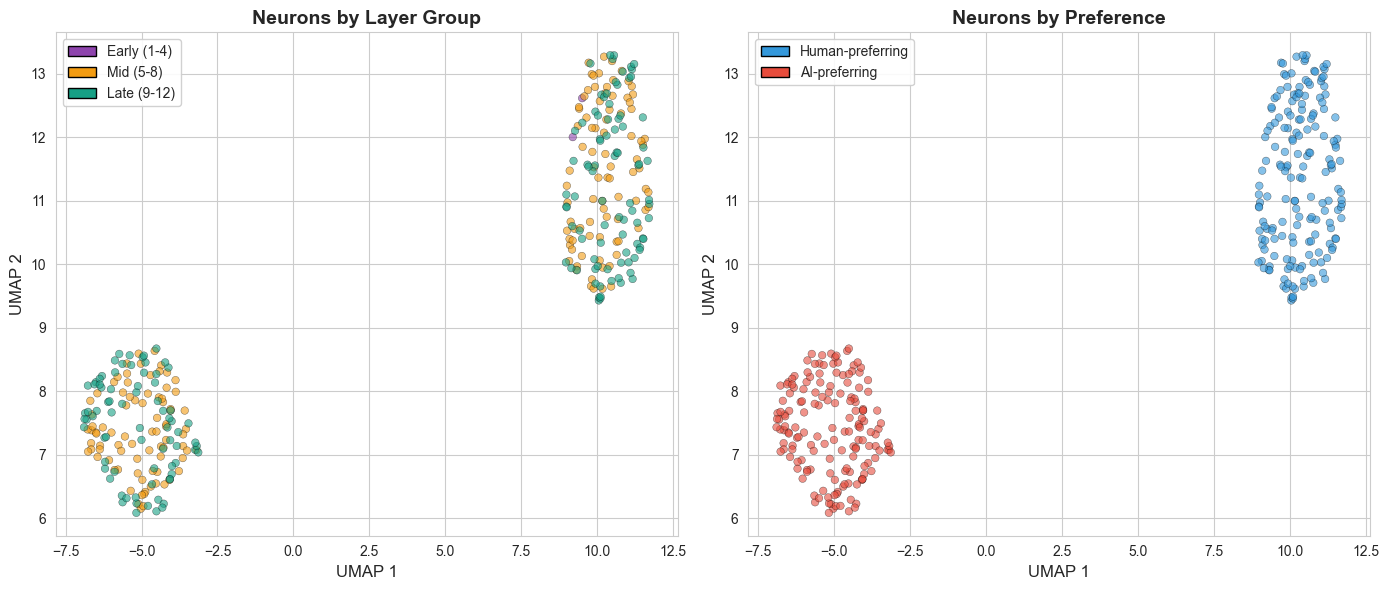

Initial UMAP visualization saved to results/figures/neuron_umap_layers_preference.png


In [4]:
# Create layer groups for visualization
def layer_to_group(layer):
    if layer <= 4:
        return 0  # Early layers (1-4)
    elif layer <= 8:
        return 1  # Mid layers (5-8)
    else:
        return 2  # Late layers (9-12)

neuron_df['layer_group'] = neuron_df['layer'].apply(layer_to_group)

# Create 2-panel figure: Layer groups and Preference
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Color by layer groups (Early, Mid, Late)
layer_colors_map = {0: '#8e44ad', 1: '#f39c12', 2: '#16a085'}  # Purple, Orange, Teal
layer_group_colors = [layer_colors_map[g] for g in neuron_df['layer_group']]

axes[0].scatter(
    embedding[:, 0], 
    embedding[:, 1],
    c=layer_group_colors,
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidths=0.3
)
axes[0].set_title('Neurons by Layer Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('UMAP 1', fontsize=12)
axes[0].set_ylabel('UMAP 2', fontsize=12)

layer_legend = [
    Patch(facecolor='#8e44ad', edgecolor='black', label='Early (1-4)'),
    Patch(facecolor='#f39c12', edgecolor='black', label='Mid (5-8)'),
    Patch(facecolor='#16a085', edgecolor='black', label='Late (9-12)')
]
axes[0].legend(handles=layer_legend, loc='best', framealpha=0.9)

# Panel 2: Color by direction (AI vs Human preference)
direction_colors_map = {'Human-preferring': '#3498db', 'AI-preferring': '#e74c3c'}  # Blue, Red
direction_colors = [direction_colors_map[d] for d in neuron_df['direction']]

axes[1].scatter(
    embedding[:, 0], 
    embedding[:, 1],
    c=direction_colors,
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidths=0.3
)
axes[1].set_title('Neurons by Preference', fontsize=14, fontweight='bold')
axes[1].set_xlabel('UMAP 1', fontsize=12)
axes[1].set_ylabel('UMAP 2', fontsize=12)

pref_legend = [
    Patch(facecolor='#3498db', edgecolor='black', label='Human-preferring'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='AI-preferring')
]
axes[1].legend(handles=pref_legend, loc='best', framealpha=0.9)

plt.tight_layout()
plt.savefig('../results/figures/neuron_umap_layers_preference.png', dpi=300, bbox_inches='tight')
plt.show()

print("Initial UMAP visualization saved to results/figures/neuron_umap_layers_preference.png")


## Hierarchical Clustering with Ward Linkage

Performing hierarchical clustering with Ward linkage...


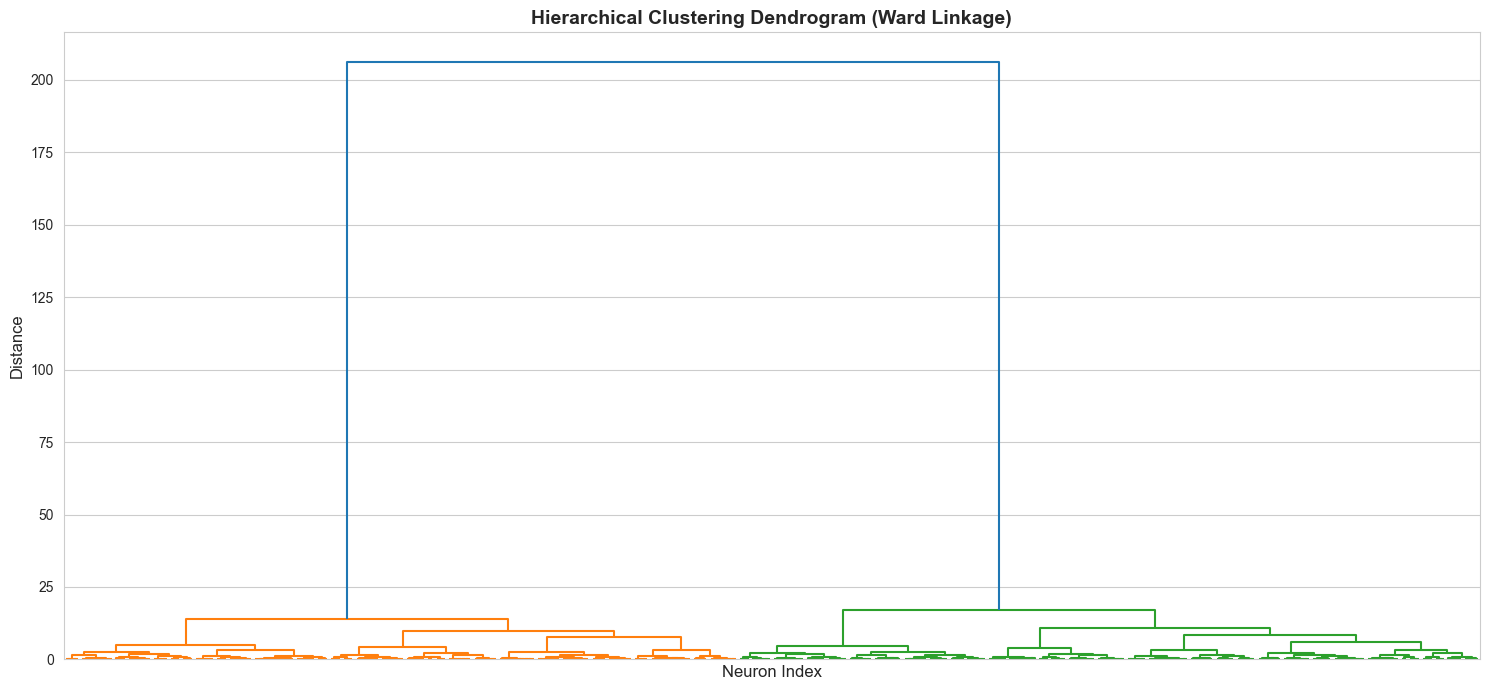

In [5]:
# Perform hierarchical clustering on UMAP embedding
print("Performing hierarchical clustering with Ward linkage...")
print("=" * 60)

# Compute linkage matrix
Z = linkage(embedding, method='ward')

# Visualize dendrogram
plt.figure(figsize=(15, 7))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Neuron Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)

## Final Clustering with Optimal K

Evaluating optimal number of clusters...
K=2: Silhouette Score = 0.8971
K=3: Silhouette Score = 0.6369
K=4: Silhouette Score = 0.3807
K=5: Silhouette Score = 0.3766
K=6: Silhouette Score = 0.3786
K=7: Silhouette Score = 0.3804
K=8: Silhouette Score = 0.3885
------------------------------------------------------------
Optimal K: 2 (Silhouette Score: 0.8971)


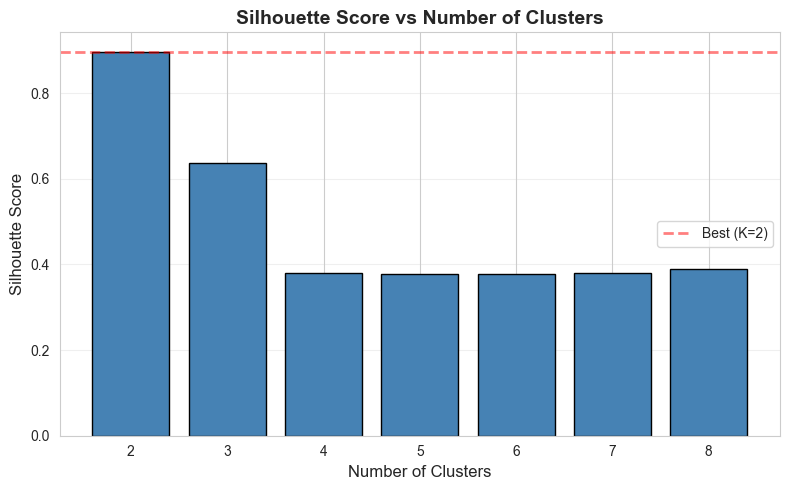


Silhouette scores saved to results/figures/neuron_clusters_silhouette_scores.png


In [6]:
# Test different numbers of clusters (3, 4, 5) and evaluate with silhouette score
print("Evaluating optimal number of clusters...")
print("=" * 60)

k_range = range(2, 9)
silhouette_scores = {}

for k in k_range:
    # Cut dendrogram to get k clusters
    clusters = fcluster(Z, t=k, criterion='maxclust')
    
    # Calculate silhouette score
    score = silhouette_score(embedding, clusters)
    silhouette_scores[k] = score
    
    print(f"K={k}: Silhouette Score = {score:.4f}")

# Find optimal K
optimal_k = max(silhouette_scores, key=silhouette_scores.get)
best_silhouette = silhouette_scores[optimal_k]

print("-" * 60)
print(f"Optimal K: {optimal_k} (Silhouette Score: {best_silhouette:.4f})")

# Visualize silhouette scores
plt.figure(figsize=(8, 5))
plt.bar(k_range, [silhouette_scores[k] for k in k_range], color='steelblue', edgecolor='black')
plt.axhline(best_silhouette, color='red', linestyle='--', linewidth=2, alpha=0.5, 
            label=f'Best (K={optimal_k})')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/neuron_clusters_silhouette_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSilhouette scores saved to results/figures/neuron_clusters_silhouette_scores.png")
print("=" * 60)

## Dendrogram with Optimal Cut


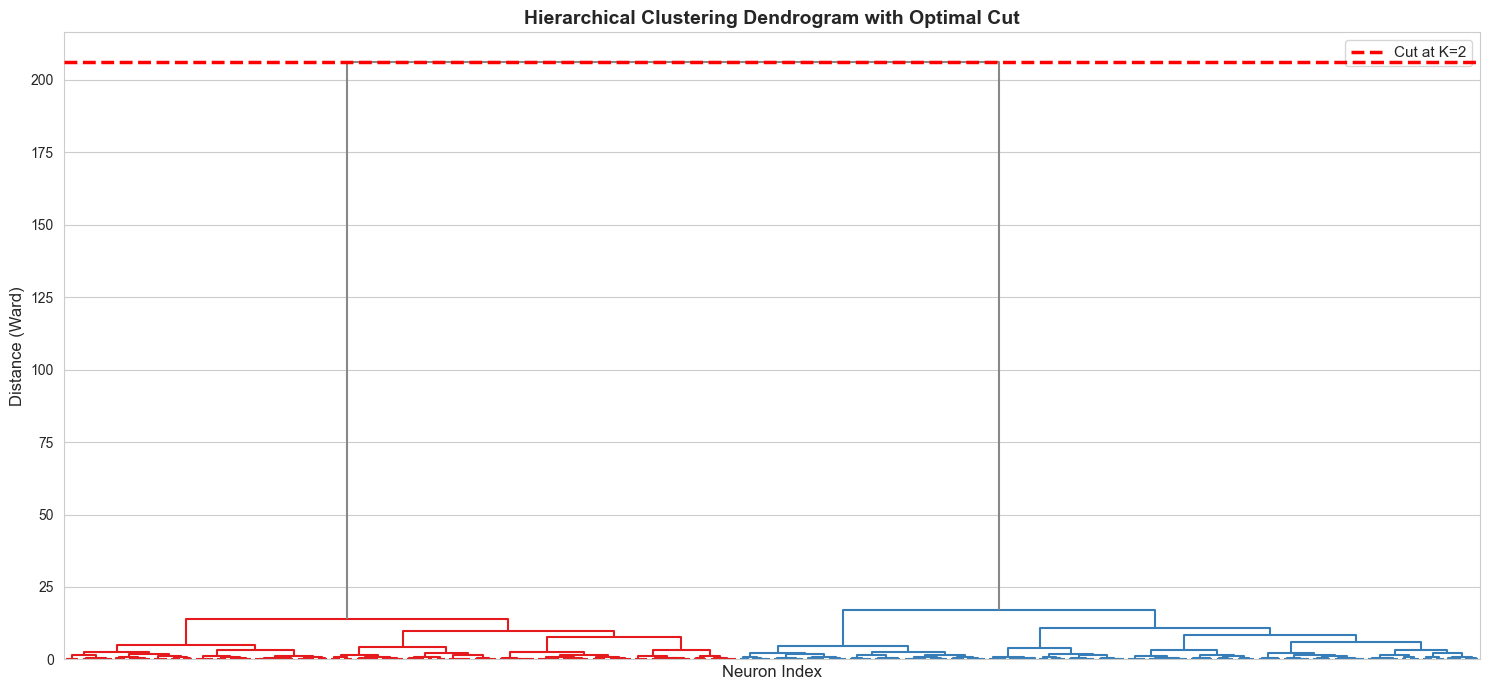

Dendrogram with K=2 cut saved to results/figures/neuron_dendrogram_cut.png


In [7]:
# Visualize dendrogram with cut line at optimal K and colored clusters
from scipy.cluster.hierarchy import dendrogram, set_link_color_palette
import matplotlib.pyplot as plt

# Use the same vibrant color palette as UMAP clusters
cluster_colors_palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'][:optimal_k]
set_link_color_palette(cluster_colors_palette)

plt.figure(figsize=(15, 7))

# Calculate the correct distance threshold for optimal_k clusters
# In linkage matrix Z, row i represents the merge at step i
# Z has shape (n-1, 4), where n is number of points
# Z[-1, 2] is the final merge distance (top of dendrogram)
# Z[-2, 2] is the second-to-last merge distance (creates 2 clusters)
# Z[-(k-1), 2] is the merge that creates k clusters
# For k=3, we want Z[-2, 2] - the height just before going from 3->2 clusters
cut_height = Z[-(optimal_k-1), 2]

# Draw dendrogram with colors below threshold
dendro = dendrogram(Z, no_labels=True, color_threshold=cut_height, above_threshold_color='#888888')

# Add cut line
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2.5, label=f'Cut at K={optimal_k}', zorder=10)

plt.title('Hierarchical Clustering Dendrogram with Optimal Cut', fontsize=14, fontweight='bold')
plt.xlabel('Neuron Index', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig('../results/figures/neuron_dendrogram_cut.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Dendrogram with K={optimal_k} cut saved to results/figures/neuron_dendrogram_cut.png")

## Final Cluster Assignment

In [8]:
# Cut dendrogram at optimal K to get final cluster assignments
n_clusters = optimal_k
neuron_clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

# Adjust to 0-indexed
neuron_clusters = neuron_clusters - 1

# Add cluster info to neuron_df
neuron_df['cluster'] = neuron_clusters

print(f"Final hierarchical clustering with K={n_clusters}")
print("=" * 60)
print(f"Neuron cluster distribution:")
for i in range(n_clusters):
    n_neurons = np.sum(neuron_clusters == i)
    print(f"  Cluster {i}: {n_neurons} neurons")
print("=" * 60)


Final hierarchical clustering with K=2
Neuron cluster distribution:
  Cluster 0: 160 neurons
  Cluster 1: 176 neurons


## UMAP with Cluster Assignment

Visualize the identified clusters in UMAP space.

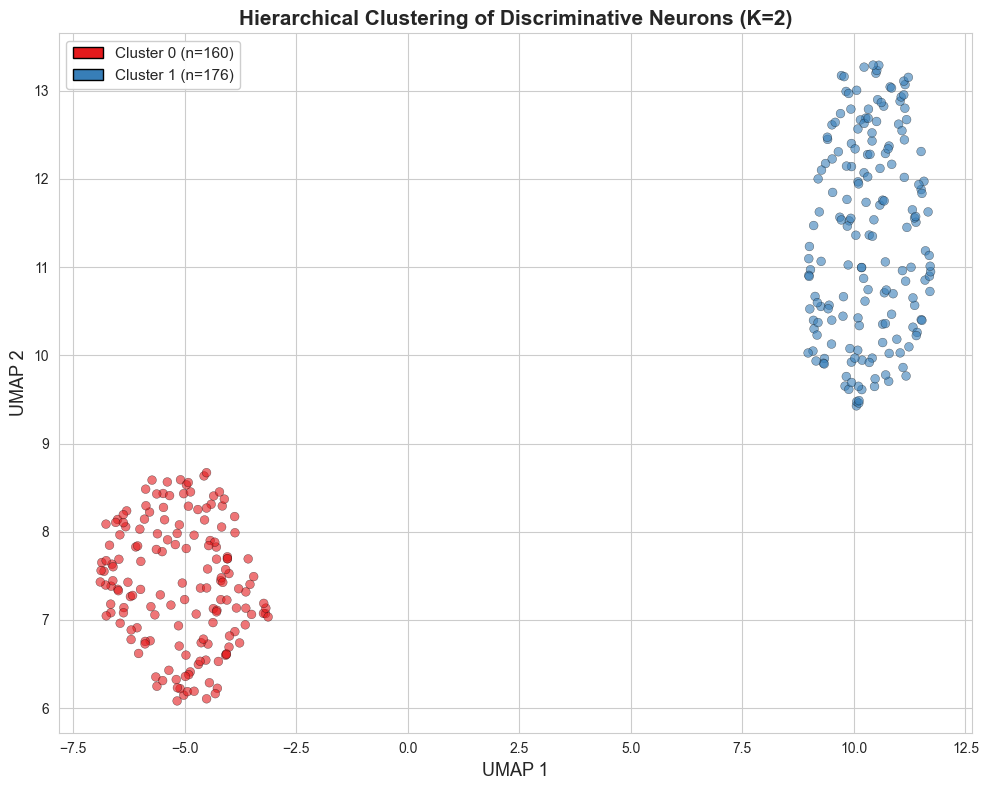

Cluster visualization saved to results/figures/neuron_umap_clusters.png


In [9]:
# Create single-panel figure showing cluster assignments
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 8))

# Define vibrant colors for clusters
cluster_colors_palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'][:n_clusters]
cluster_colors = [cluster_colors_palette[c] for c in neuron_clusters]

ax.scatter(
    embedding[:, 0], 
    embedding[:, 1],
    c=cluster_colors,
    alpha=0.6,
    s=40,
    edgecolors='black',
    linewidths=0.3
)
ax.set_title(f'Hierarchical Clustering of Discriminative Neurons (K={n_clusters})', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('UMAP 1', fontsize=13)
ax.set_ylabel('UMAP 2', fontsize=13)

# Add legend for clusters
legend_elements = [Patch(facecolor=cluster_colors_palette[i], edgecolor='black', 
                         label=f'Cluster {i} (n={np.sum(neuron_clusters == i)})')
                   for i in range(n_clusters)]
ax.legend(handles=legend_elements, loc='best', framealpha=0.95, fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/neuron_umap_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("Cluster visualization saved to results/figures/neuron_umap_clusters.png")

## Cluster Analysis

In [10]:
# Analyze cluster properties
print("=" * 80)
print("NEURON CLUSTER ANALYSIS")
print("=" * 80)

for cluster_id in range(n_clusters):
    cluster_neurons = neuron_df[neuron_df['cluster'] == cluster_id]
    
    print(f"\nCluster {cluster_id}: {len(cluster_neurons)} neurons")
    print("-" * 80)
    
    # Layer distribution
    print("  Layer distribution:")
    layer_counts = cluster_neurons['layer'].value_counts().sort_index()
    for layer, count in layer_counts.items():
        pct = count / len(cluster_neurons) * 100
        print(f"    Layer {layer:2d}: {count:3d} neurons ({pct:5.1f}%)")
    
    # Direction preference
    print("\n  Direction preference:")
    direction_counts = cluster_neurons['direction'].value_counts()
    for direction, count in direction_counts.items():
        pct = count / len(cluster_neurons) * 100
        print(f"    {direction}: {count:3d} neurons ({pct:5.1f}%)")
    
    # AUC statistics
    print("\n  AUC statistics:")
    print(f"    Mean AUC: {cluster_neurons['auc'].mean():.4f}")
    print(f"    Std AUC:  {cluster_neurons['auc'].std():.4f}")
    print(f"    Mean AUC deviation: {cluster_neurons['auc_deviation'].mean():.4f}")

print("\n" + "=" * 80)


NEURON CLUSTER ANALYSIS

Cluster 0: 160 neurons
--------------------------------------------------------------------------------
  Layer distribution:
    Layer  5:   4 neurons (  2.5%)
    Layer  6:   5 neurons (  3.1%)
    Layer  7:  29 neurons ( 18.1%)
    Layer  8:  45 neurons ( 28.1%)
    Layer  9:  34 neurons ( 21.2%)
    Layer 10:  22 neurons ( 13.8%)
    Layer 11:  12 neurons (  7.5%)
    Layer 12:   9 neurons (  5.6%)

  Direction preference:
    AI-preferring: 160 neurons (100.0%)

  AUC statistics:
    Mean AUC: 0.7392
    Std AUC:  0.0335
    Mean AUC deviation: 0.2392

Cluster 1: 176 neurons
--------------------------------------------------------------------------------
  Layer distribution:
    Layer  3:   2 neurons (  1.1%)
    Layer  6:   2 neurons (  1.1%)
    Layer  7:  30 neurons ( 17.0%)
    Layer  8:  55 neurons ( 31.2%)
    Layer  9:  42 neurons ( 23.9%)
    Layer 10:  27 neurons ( 15.3%)
    Layer 11:  12 neurons (  6.8%)
    Layer 12:   6 neurons (  3.4%)

  Di

## Summary Statistics

In [11]:
# Print final summary
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\nTotal discriminative neurons: {X_neurons.shape[0]}")
print(f"Samples per neuron: {X_neurons.shape[1]}")
print(f"Optimal K (based on Silhouette Score): {n_clusters}")
print(f"Best Silhouette Score: {best_silhouette:.4f}")
print(f"\nOverall direction distribution:")
print(neuron_df['direction'].value_counts())
print(f"\nOverall layer distribution:")
print(neuron_df['layer'].value_counts().sort_index())
print("\n" + "=" * 80)

FINAL SUMMARY

Total discriminative neurons: 336
Samples per neuron: 10000
Optimal K (based on Silhouette Score): 2
Best Silhouette Score: 0.8971

Overall direction distribution:
direction
Human-preferring    176
AI-preferring       160
Name: count, dtype: int64

Overall layer distribution:
layer
3       2
5       4
6       7
7      59
8     100
9      76
10     49
11     24
12     15
Name: count, dtype: int64



## Cluster Exemplar Analysis

For each cluster we select **5 AI** and **5 Human** text samples that maximally contrast the cluster's activation against all other clusters.

**Score formula** — for sample *s* and cluster *k*:

$$\text{specificity}_k(s) = R_k(s) - \frac{1}{K-1}\sum_{j \ne k} R_j(s)$$

where $R_k(s) = \frac{1}{|C_k|} \sum_{i \in C_k} z_i(s)$ is the mean z-normalised activation of cluster *k*'s neurons in sample *s*.

- **AI exemplars** of cluster *k*: the 5 AI samples with the **highest** specificity score — texts where cluster *k* fires most relative to other clusters.
- **Human exemplars** of cluster *k*: the 5 Human samples with the **lowest** specificity score — texts where cluster *k* is most suppressed and other clusters dominate.

This gives maximum contrast per cluster and generalises to any number of clusters.


In [12]:
from datasets import load_from_disk, concatenate_datasets
from transformers import AutoTokenizer

TOKENIZED_PATH = "../data/processed/AI_Human/tokenized/bert-base-uncased"
SPLIT = "test"
SAMPLES_PER_CLASS = 5000  # must match extract_activations settings

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Load the exact split used during activation extraction
tok_dict = load_from_disk(TOKENIZED_PATH)
full_split = tok_dict[SPLIT]

# Reproduce the same balanced shuffle used in ActivationExtractor.extract_activations()
ai_samples   = full_split.filter(lambda x: x["label"] == 1)
human_samples = full_split.filter(lambda x: x["label"] == 0)

ai_subset    = ai_samples.shuffle(seed=42).select(range(min(SAMPLES_PER_CLASS, len(ai_samples))))
human_subset = human_samples.shuffle(seed=42).select(range(min(SAMPLES_PER_CLASS, len(human_samples))))

ordered_dataset = concatenate_datasets([ai_subset, human_subset]).shuffle(seed=42)

print(f"Reconstructed dataset size: {len(ordered_dataset)}")

# Sanity check: labels must match what was saved during extraction
reconstructed_labels = np.array(ordered_dataset["label"])
mismatch = np.sum(reconstructed_labels != labels)
if mismatch == 0:
    print("✓ Labels verified — sampling order matches activation files exactly")
else:
    print(f"⚠ WARNING: {mismatch} label mismatches detected — check HF dataset version / tokenizer script")


Filter:   0%|          | 0/45000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/45000 [00:00<?, ? examples/s]

Reconstructed dataset size: 10000
✓ Labels verified — sampling order matches activation files exactly


C:\Users\Pawel\AppData\Local\Temp\ipykernel_10172\1901468036.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  reconstructed_labels = np.array(ordered_dataset["label"])


In [13]:
# ── Step 1: z-normalise every neuron across all 10 000 samples ──────────────
# X_neurons: shape (n_discriminative_neurons, n_samples)
neuron_mean = X_neurons.mean(axis=1, keepdims=True)   # per-neuron mean
neuron_std  = X_neurons.std(axis=1,  keepdims=True)   # per-neuron std
X_z = (X_neurons - neuron_mean) / (neuron_std + 1e-8) # (n_neurons, n_samples)

# ── Step 2: R_k(s) = mean z-score of cluster k's neurons in sample s ────────
# For AI-preferring neurons  (AUC > 0.5): high activation → high z → high R → AI-like
# For Human-preferring neurons (AUC < 0.5): high activation → high z → high R → Human-like
# Both are "in the right direction" for their own class, so no sign flip needed.

cluster_ids = sorted(neuron_df["cluster"].unique())
R = {}  # cluster_id -> (n_samples,) array
for k in cluster_ids:
    mask = neuron_df["cluster"].values == k
    R[k] = X_z[mask, :].mean(axis=0)

# ── Step 3: specificity_k(s) = R_k(s) − mean_{j≠k} R_j(s) ─────────────────
specificity = {}
for k in cluster_ids:
    others = np.mean([R[j] for j in cluster_ids if j != k], axis=0)
    specificity[k] = R[k] - others

# Summary
print("Cluster specificity score statistics (across all 10 000 samples):")
print(f"{'Cluster':>8}  {'min':>8}  {'mean':>8}  {'max':>8}")
print("─" * 44)
for k in cluster_ids:
    s = specificity[k]
    print(f"{k:>8}  {s.min():>8.3f}  {s.mean():>8.3f}  {s.max():>8.3f}")


Cluster specificity score statistics (across all 10 000 samples):
 Cluster       min      mean       max
────────────────────────────────────────────
       0    -3.113     0.000     2.014
       1    -2.014    -0.000     3.113


In [14]:
TOP_N = 5  # exemplars per class per cluster
TEXT_PREVIEW = 500  # max characters to display per sample


def get_text(idx: int) -> str:
    """Decode BERT input_ids back to readable text (lowercase, ~512 tokens max)."""
    return tokenizer.decode(ordered_dataset[int(idx)]["input_ids"], skip_special_tokens=True)


def print_exemplars(cluster_id: int, ai_indices, human_indices, scores):
    cluster_info = neuron_df[neuron_df["cluster"] == cluster_id]
    direction = cluster_info["direction"].value_counts().index[0]
    n_neurons = len(cluster_info)

    print(f"\n{'═'*80}")
    print(f"  CLUSTER {cluster_id}  |  {n_neurons} neurons  |  {direction}")
    print(f"{'═'*80}")

    # ── AI exemplars ──────────────────────────────────────────────────────────
    print(f"\n  ▶ AI EXEMPLARS  (cluster {cluster_id} maximally active vs other clusters)")
    print(f"  {'─'*76}")
    for rank, idx in enumerate(ai_indices, 1):
        text = get_text(idx)
        preview = text[:TEXT_PREVIEW] + " [...]" if len(text) > TEXT_PREVIEW else text
        print(f"\n  [AI #{rank}]  sample_idx={idx}  score={scores[idx]:+.4f}")
        print(f"  {preview}")

    # ── Human exemplars ───────────────────────────────────────────────────────
    print(f"\n  ▶ HUMAN EXEMPLARS  (cluster {cluster_id} maximally suppressed vs other clusters)")
    print(f"  {'─'*76}")
    for rank, idx in enumerate(human_indices, 1):
        text = get_text(idx)
        preview = text[:TEXT_PREVIEW] + " [...]" if len(text) > TEXT_PREVIEW else text
        print(f"\n  [Human #{rank}]  sample_idx={idx}  score={scores[idx]:+.4f}")
        print(f"  {preview}")


# ── Exemplar extraction ───────────────────────────────────────────────────────
ai_mask    = labels == 1
human_mask = labels == 0

for k in cluster_ids:
    scores = specificity[k]

    # AI: highest specificity_k among AI samples
    ai_score_masked = np.where(ai_mask, scores, -np.inf)
    top_ai = np.argsort(ai_score_masked)[-TOP_N:][::-1]

    # Human: lowest specificity_k among Human samples ("revert the equation")
    human_score_masked = np.where(human_mask, scores, np.inf)
    bottom_human = np.argsort(human_score_masked)[:TOP_N]

    print_exemplars(k, top_ai, bottom_human, scores)



════════════════════════════════════════════════════════════════════════════════
  CLUSTER 0  |  160 neurons  |  AI-preferring
════════════════════════════════════════════════════════════════════════════════

  ▶ AI EXEMPLARS  (cluster 0 maximally active vs other clusters)
  ────────────────────────────────────────────────────────────────────────────

  [AI #1]  sample_idx=3415  score=+2.0138
  constance merritt is an american poet. born in lawrence, kansas, merritt is one of the most highly acclaimed and influential poets of her generation. her poems are often surreal and experimental, exploring themes such as love, loss, and betrayal. her work has been published in publications such as the new yorker, harper ' s magazine, and poetry magazine. merritt currently teaches at the university of california, riverside.

  [AI #2]  sample_idx=723  score=+1.9508
  edward wegman is an american statistician and computer scientist. he is the john d. and catherine t. macarthur professor in engine